## Figure 3 — Benchmark panels b–f

**b** AUROC · **c** Average Precision · **d** ImmunoMTL vs Shuffle · **e** AUROC by MMS cluster · **f** AP by MMS cluster

Prerequisites (run from `scripts/`):
```
python eval_metrics.py   # → results/BenchmarkSet_metrics.csv + bootstrap CSVs
python eval_subset.py    # → analysis/groupwise_bootstrap/*.csv
```

In [204]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Run from notebook/, analysis/, or repo root
_here = os.path.abspath('.')
if os.path.basename(_here) in ('notebook', 'analysis'):
    os.chdir(os.path.dirname(_here))

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
matplotlib.rcParams['font.size']    = 9

FIG_DIR  = 'analysis/figures'
BOOT_DIR = 'analysis/groupwise_bootstrap'
os.makedirs(FIG_DIR, exist_ok=True)

def find_csv(fname):
    for base in ['results', 'analysis']:
        p = os.path.join(base, fname)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f'{fname} not found in results/ or analysis/')

In [205]:
# ── Palette & display names ───────────────────────────────────────────────────

MODEL_ORDER = ['ImmunoMTL', 'STL', 'ABC', 'JointSTL',
               'BigMHC', 'PRIME2', 'MUNIS', 'netMHCpan', 'MHCflurry']

COLORS = {
    'ImmunoMTL': '#4E526E',
    'STL':       '#E07A5F',
    'ABC':       '#B8A8C8',
    'JointSTL':  '#8BAAB8',
    'Shuffle':   '#D3D3D3',
    'BigMHC':    '#F6D5A0',
    'MUNIS':     '#92BEAA',
    'PRIME2':    '#718B8E',
    'netMHCpan': '#606060',
    'MHCflurry': '#F0C3AF',
}

DISPLAY = {
    'ImmunoMTL': 'ImmunoMTL',
    'STL':       'ImmunoSTL',
    'ABC':       'ImmunoABC',
    'JointSTL':  'JointSTL',
    'Shuffle':   'Shuffle',
    'BigMHC':    'BigMHC',
    'MUNIS':     'MUNIS',
    'PRIME2':    'PRIME 2.0',
    'netMHCpan': 'netMHCpan 4.1',
    'MHCflurry': 'MHCflurry 2.0',
}

In [206]:
# ── Load point estimates and bootstrap distributions ──────────────────────────

metrics_df = pd.read_csv(find_csv('BenchmarkSet_metrics.csv')).set_index('Model')

boot = {
    'AUROC': pd.read_csv(find_csv('BenchmarkSet_bootstrap_natural_AUROC.csv')),
    'AP':    pd.read_csv(find_csv('BenchmarkSet_bootstrap_natural_AP.csv')),
}

def ci95(series):
    return np.percentile(series.dropna(), [2.5, 97.5])

metrics_df

,AUROC,AP,PPVn,AUROC_std,AP_std,PPVn_std
Model,,,,,,
ImmunoMTL,0.578283,0.518699,0.508961,NaN,NaN,NaN
STL,0.546071,0.493742,0.484767,NaN,NaN,NaN
ABC,0.541249,0.484786,0.483871,NaN,NaN,NaN
JointSTL,0.536083,0.470836,0.474910,NaN,NaN,NaN
netMHCpan,0.439194,0.427913,0.424731,NaN,NaN,NaN
MHCflurry,0.422877,0.413442,0.402330,NaN,NaN,NaN
PRIME2,0.490944,0.467821,0.444444,NaN,NaN,NaN
BigMHC,0.466895,0.458495,0.429211,NaN,NaN,NaN
MUNIS,0.464451,0.444848,0.432796,NaN,NaN,NaN


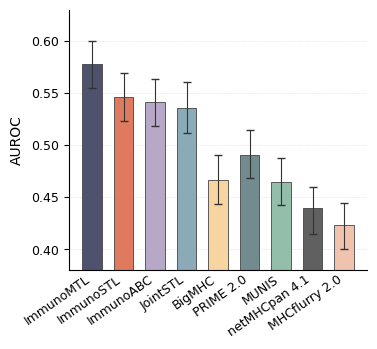

Saved analysis/figures/fig3_b.{pdf,png}


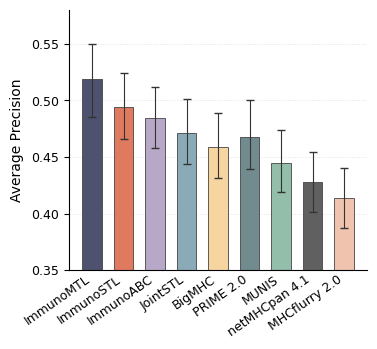

Saved analysis/figures/fig3_c.{pdf,png}


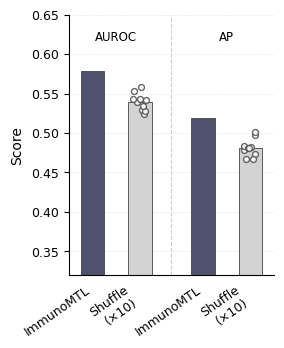

Saved analysis/figures/fig3_d.{pdf,png}


In [207]:
# ── Panels b, c, d — saved as separate figures ───────────────────────────────
from sklearn.metrics import roc_auc_score, average_precision_score

BAR_PANELS = [
    ('AUROC', 'AUROC',             (0.38, 0.63), 'fig3_b'),
    ('AP',    'Average Precision', (0.35, 0.58), 'fig3_c'),
]

# Load per-seed Shuffle scores for panel d
shuf_aurocs, shuf_aps = [], []
for s in range(1, 11):
    p = f"pred_results/immunomtl_shuffle_s1-10/s{s}_BenchmarkSet.csv"
    if not os.path.exists(p):
        continue
    df_s = pd.read_csv(p)
    yt   = df_s['Label'].values.astype(float)
    yp   = df_s['Predicted Score'].values.astype(float)
    shuf_aurocs.append(roc_auc_score(yt, yp))
    shuf_aps.append(average_precision_score(yt, yp))

mtl_auroc = float(metrics_df.loc['ImmunoMTL', 'AUROC'])
mtl_ap    = float(metrics_df.loc['ImmunoMTL', 'AP'])

# ── Panels b, c — one figure each ────────────────────────────────────────────
for metric, ylabel, ylim, fname in BAR_PANELS:
    bdf = boot[metric]
    fig, ax = plt.subplots(figsize=(3.6, 4.2))
    fig.subplots_adjust(bottom=0.30, top=0.92, left=0.14, right=0.97)

    for i, model in enumerate(MODEL_ORDER):
        if model not in metrics_df.index:
            continue
        val   = float(metrics_df.loc[model, metric])
        color = COLORS[model]
        ax.bar(i, val, width=0.62, color=color,
               edgecolor='#444444', linewidth=0.6)
        if model in bdf.columns:
            lo, hi = ci95(bdf[model])
            ax.errorbar(i, val, yerr=[[val - lo], [hi - val]],
                        fmt='none', color='#333333', capsize=3, linewidth=0.8, zorder=4)

    ax.set_xticks(np.arange(len(MODEL_ORDER)))
    ax.set_xticklabels([DISPLAY[m] for m in MODEL_ORDER],
                       rotation=35, ha='right', fontsize=8.5)
    ax.tick_params(axis='x', length=0, pad=2, labelsize=9)
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=5, color='#000000')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='y', labelsize=9, width=0.8)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.6, color='#DDDDDD', zorder=0)
    ax.set_axisbelow(True)

    plt.savefig(os.path.join(FIG_DIR, f'{fname}.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, f'{fname}.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved analysis/figures/{fname}.{{pdf,png}}')

# ── Panel d — ImmunoMTL vs Shuffle ───────────────────────────────────────────
gbw    = 0.15
gap    = 0.15
x_grps = np.array([0.0, 0.7])   # tighter spacing to match thinner bars
x_mtl  = x_grps - gbw / 2 - gap / 2
x_shuf = x_grps + gbw / 2 + gap / 2

panel_d_data = [
    (mtl_auroc, np.mean(shuf_aurocs), shuf_aurocs, 'AUROC'),
    (mtl_ap,    np.mean(shuf_aps),    shuf_aps,    'AP'),
]

ylim_d  = (0.32, 0.65)
label_y = 0.63

fig, ax = plt.subplots(figsize=(2.6, 4.2))
fig.subplots_adjust(bottom=0.30, top=0.92, left=0.18, right=0.97)

shuf_c = COLORS['Shuffle']
mtl_c  = COLORS['ImmunoMTL']
rng_j  = np.random.default_rng(0)

for g, (mtl_v, shuf_v, seed_vals, grp_label) in enumerate(panel_d_data):
    ax.bar(x_mtl[g],  mtl_v,  width=gbw, color=mtl_c,
           edgecolor='#444444', linewidth=0.6)
    ax.bar(x_shuf[g], shuf_v, width=gbw, color=shuf_c,
           edgecolor='#444444', linewidth=0.6)
    jit = rng_j.uniform(-gbw * 0.28, gbw * 0.28, len(seed_vals))
    ax.scatter(x_shuf[g] + jit, seed_vals, s=18, zorder=5,
               color='white', edgecolors='#555555', linewidths=1, alpha=0.9)
    ax.text(float(np.mean([x_mtl[g], x_shuf[g]])), label_y, grp_label,
            ha='center', va='top', fontsize=8.5, color='#000000')

ax.axvline(float(np.mean([x_shuf[0], x_mtl[1]])),
           color='#CCCCCC', linewidth=0.8, linestyle='--', zorder=0)

ax.set_xticks([x_mtl[0], x_shuf[0], x_mtl[1], x_shuf[1]])
ax.set_xticklabels(['ImmunoMTL', 'Shuffle\n(×10)', 'ImmunoMTL', 'Shuffle\n(×10)'],
                    fontsize=7.5, ha='right', rotation=35)
ax.tick_params(axis='x', length=0, pad=6, labelsize=9)
ax.set_xlim(x_mtl[0] - gbw, x_shuf[1] + gbw)
ax.set_ylim(*ylim_d)
ax.set_ylabel('Score', fontsize=10, labelpad=5, color='#000000')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='y', labelsize=9, width=0.8)
ax.yaxis.grid(True, linestyle=':', linewidth=0.6, color='#DDDDDD', zorder=0)
ax.set_axisbelow(True)


plt.savefig(os.path.join(FIG_DIR, 'fig3_d.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig3_d.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved analysis/figures/fig3_d.{pdf,png}')

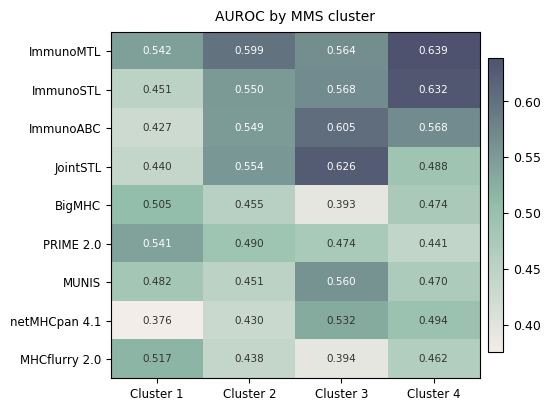

Saved analysis/figures/fig3_e.{pdf,png}


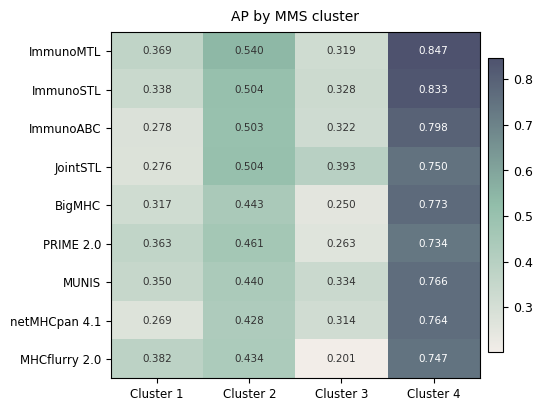

Saved analysis/figures/fig3_f.{pdf,png}


In [208]:
# ── Panels e, f — AUROC / AP by MMS cluster (heatmap, saved separately) ──────
from matplotlib.colors import LinearSegmentedColormap

morandi_cmap = LinearSegmentedColormap.from_list(
    'morandi', ['#F2EDE8', '#92BEAA', '#4E526E']
)

cluster_vals   = [0.0, 1.0, 2.0, 3.0]
cluster_labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for metric, fname in [('AUROC', 'fig3_e'), ('AP', 'fig3_f')]:
    mat_rows, row_labels = [], []
    for model in MODEL_ORDER:
        vals = []
        for val in cluster_vals:
            csv = os.path.join(BOOT_DIR,
                               f'BenchmarkSet_bootstrap_MMS_Cluster_{val}_{metric}.csv')
            if os.path.exists(csv):
                df = pd.read_csv(csv)
                vals.append(df[model].mean() if model in df.columns else np.nan)
            else:
                vals.append(np.nan)
        if not all(np.isnan(v) for v in vals):
            mat_rows.append(vals)
            row_labels.append(DISPLAY[model])

    mat  = np.array(mat_rows)
    vmin = np.nanmin(mat)
    vmax = np.nanmax(mat)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    fig.subplots_adjust(left=0.18, right=0.92, top=0.92, bottom=0.15)

    im = ax.imshow(mat, aspect='auto', cmap=morandi_cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(cluster_labels)))
    ax.set_xticklabels(cluster_labels, fontsize=8.5, ha='center')
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8.5)
    ax.set_title(f'{metric} by MMS cluster', fontsize=10, pad=8)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if np.isnan(v):
                continue
            norm_v = (v - vmin) / (vmax - vmin + 1e-8)
            txt_c  = 'white' if norm_v > 0.6 else '#333333'
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=7.5, color=txt_c)

    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)

    plt.savefig(os.path.join(FIG_DIR, f'{fname}.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, f'{fname}.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved analysis/figures/{fname}.{{pdf,png}}')

1:5 AUROC columns: ['ImmunoMTL', 'STL', 'ABC', 'JointSTL', 'netMHCpan', 'MHCflurry', 'PRIME2', 'BigMHC', 'MUNIS']


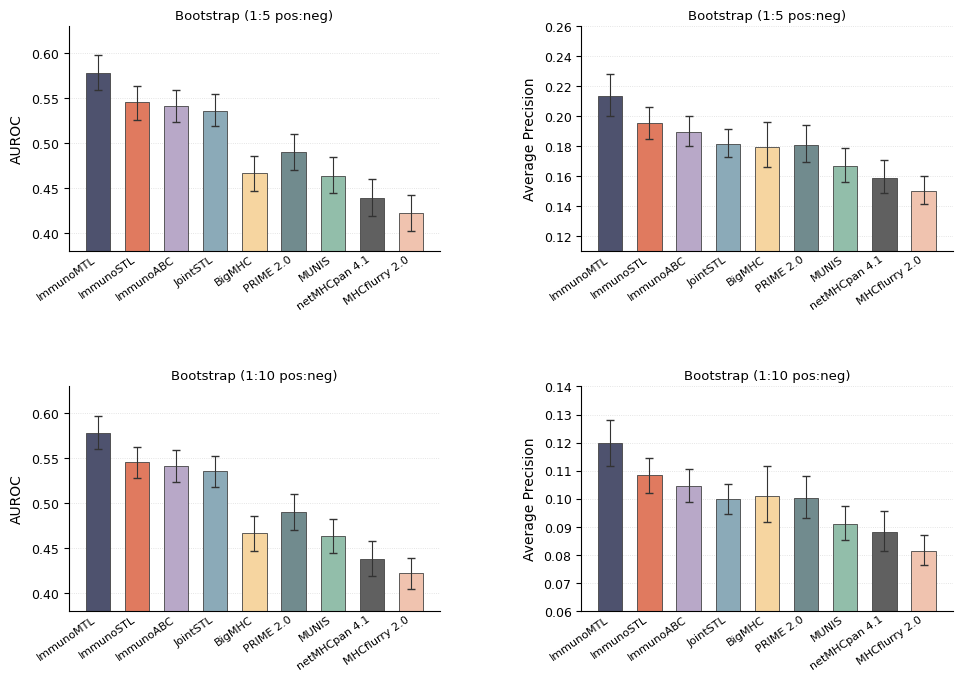

Saved analysis/sup_figures/fig_ratio.{pdf,png}


In [209]:
# ── Ratio panels — AUROC / AP at 1:5 and 1:10 pos:neg ────────────────────────
# Generated by: python scripts/eval_metrics.py  (outputs to results/)

SUP_FIG_DIR  = 'analysis/sup_figures'

ratios = {
    '1:5':  {'AUROC': pd.read_csv(find_csv('BenchmarkSet_bootstrap_1_5_AUROC.csv')),
             'AP':    pd.read_csv(find_csv('BenchmarkSet_bootstrap_1_5_AP.csv'))},
    '1:10': {'AUROC': pd.read_csv(find_csv('BenchmarkSet_bootstrap_1_10_AUROC.csv')),
             'AP':    pd.read_csv(find_csv('BenchmarkSet_bootstrap_1_10_AP.csv'))},
}

# Use the same model order as panels b/c; skip any absent in ratio files
RATIO_ORDER = MODEL_ORDER  # excludes Shuffle (mean over 10 seeds)
RATIO_YLIM = {
    'AUROC': {'1:5': (0.38, 0.63), '1:10': (0.38, 0.63)},
    'AP':    {'1:5': (0.11, 0.26), '1:10': (0.06, 0.14)},
}
RATIO_YLABEL = {'AUROC': 'AUROC',      'AP': 'Average Precision'}

print('1:5 AUROC columns:', list(ratios['1:5']['AUROC'].columns))

fig, axes = plt.subplots(2, 2, figsize=(10.4, 7.8))
fig.subplots_adjust(left=0.12, right=0.97, top=0.93, bottom=0.18,
                    hspace=0.60, wspace=0.38)

for row_idx, (ratio_label, ratio_data) in enumerate(ratios.items()):
    for col_idx, metric in enumerate(['AUROC', 'AP']):
        ax  = axes[row_idx, col_idx]
        bdf = ratio_data[metric]
        # Only models present in the bootstrap file
        present = [m for m in RATIO_ORDER if m in bdf.columns]
        xs = np.arange(len(present))

        for i, model in enumerate(present):
            val    = float(bdf[model].mean())
            lo, hi = ci95(bdf[model])
            ax.bar(i, val, width=0.62, color=COLORS[model],
                   edgecolor='#444444', linewidth=0.6, zorder=3)
            ax.errorbar(i, val, yerr=[[val - lo], [hi - val]],
                        fmt='none', color='#333333', capsize=3,
                        linewidth=0.8, zorder=4)

        ax.set_title(f'Bootstrap ({ratio_label} pos:neg)', fontsize=9.5,
                     loc='center', pad=5, color='#000000')
        ax.set_xticks(xs)
        ax.set_xticklabels([DISPLAY.get(m, m) for m in present],
                           rotation=35, ha='right', fontsize=8)
        ax.tick_params(axis='x', length=0, pad=2)
        ax.set_ylim(*RATIO_YLIM[metric][ratio_label])
        ax.set_ylabel(RATIO_YLABEL[metric], fontsize=10, labelpad=5)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.spines['left'].set_zorder(4)
        ax.spines['bottom'].set_zorder(4)
        ax.tick_params(axis='y', labelsize=9, width=0.8)
        ax.yaxis.grid(True, linestyle=':', linewidth=0.6, color='#DDDDDD', zorder=0)
        ax.set_axisbelow(True)

plt.savefig(os.path.join(SUP_FIG_DIR, 'fig_ratio.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(SUP_FIG_DIR, 'fig_ratio.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved analysis/sup_figures/fig_ratio.{pdf,png}')
